In [1]:
'''
 # @ Author: Lex Albrandt
 # @ Class: CS440
 # @ Assignment: Assignment 4
 # @ Description: This is the code for assignment 4
 '''

'\n # @ Author: Lex Albrandt\n # @ Class: CS440\n # @ Assignment: Assignment 4\n # @ Description: This is the code for assignment 4\n '

# Question 1

In [2]:
import numpy as np
import torch
import torchvision
import torchvision.transforms as transforms
from torchvision import datasets
from sklearn.cluster import KMeans
import torch.nn as nn
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader, Subset

In [3]:
#-------------------------------------
# 1. Load CIFAR-10
# ------------------------------------

transform = transforms.Compose([transforms.ToTensor()])

dataset = torchvision.datasets.CIFAR10(
    root = './data',
    train = True,
    download = True,
    transform = transform
)

# shape (50000, 32, 32, 3)
images = dataset.data
labels = np.array(dataset.targets)

/home/lexlexpdx/Desktop/valinor/school/cs440/homework4/myenv/lib/python3.12/site-packages/torchvision/datasets/cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")


In [4]:
# --------------------------------------
# 2. Select 100 images per class
# --------------------------------------
samples_per_class = 100
class_counts = [0] * 10

selected_images = []
selected_labels = []

for img, label in zip(images, labels):
    if class_counts[label] < samples_per_class:
        selected_images.append(img)
        selected_labels.append(label)
        class_counts[label] += 1
        
    if len(selected_images) == 1000:
        break

X = np.array(selected_images)
y = np.array(selected_labels)

In [5]:
# -----------------------------------
# 3. Flatten images for KMeans
# -----------------------------------

X_flat = X.reshape(1000, -1)

In [6]:
# -----------------------------------
# 4. Run KMeans (k = 10)
# -----------------------------------

kmeans = KMeans(n_clusters = 10, random_state = 0, n_init = 10)
clusters = kmeans.fit_predict(X_flat)

In [7]:
# -----------------------------------
# 5. Build 10 x 10 table
# rows = true class
# columns = cluster
# -----------------------------------
table = np.zeros((10, 10), dtype = int)

for true_label, cluster in zip(y, clusters):
    table[true_label][cluster] += 1
    
print("10x10 Clustering table:")
print(table)

10x10 Clustering table:
[[ 9 16 28 11  5  4 19  0  6  2]
 [15 11  4 19 17 13  4 10  4  3]
 [ 5  3 11  4 12 27 22  2  2 12]
 [15  2  8  7 12 16 16 10  4 10]
 [ 3  2  2  3 14 28 15 20  2 11]
 [18  0  3  3  7 17 13 25  2 12]
 [ 8  0  1  3 21 26  9 14  5 13]
 [ 9  2  3  8 11 17 12 15 17  6]
 [ 9 27  3 31  3  6 13  5  3  0]
 [ 3 13  1 20 13 12  5  3 29  1]]


In [8]:
# -----------------------------------
# 6. Compute clusering accuracy
# -----------------------------------
correct = 0
for j in range(10):
    correct += np.max(table[:, j])

accuracy = correct / 1000

print(f"\nClustering Accuracy: {accuracy}")


Clustering Accuracy: 0.242


The accuracy for the kclustering is much lower than the accuracy for the first  
assignement because kclustering is an unsupervised learning method, which means  
the alogrithm does not use true class labels during training. In contrast, the  
first assignment used a fully connected neural network which is a supervised  
approach, so the model is trained directly using labeled examples. In that  
assignment the accuracy was around 85-90%.  
  

# Question 2

In [9]:
X = np.array(selected_images)
y = np.array(selected_labels)

X = torch.tensor(X).float() / 255
X = X.permute(0, 3, 1, 2)

In [10]:
# ---------------------------------
# Build autoencoder
# ---------------------------------

class Autoencoder(nn.Module):
    
    def __init__(self):
        super().__init__()
        
        self.encoder = nn.Sequential(
            nn.Flatten(),
            nn.Linear(3072, 512),
            nn.ReLU(),
            nn.Linear(512, 128),
            nn.ReLU()
        )

        self.decoder = nn.Sequential(
            nn.Linear(128, 512),
            nn.ReLU(),
            nn.Linear(512, 3072),
            nn.Sigmoid()
        )

    def forward(self, x):
        z = self.encoder(x)
        x_hat = self.decoder(z)
        return x_hat

In [11]:
# ------------------------------
# Train the autoencoder
# ------------------------------

model = Autoencoder()

criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr = 0.001)

X_flat = X.reshape(1000, -1)

for epoch in range(30):
    
    optimizer.zero_grad()

    output = model(X_flat)

    loss = criterion(output, X_flat)

    loss.backward()
    optimizer.step()
    
    print(f"Epoch {epoch + 1}, Loss: {loss.item()}")

Epoch 1, Loss: 0.06365760415792465
Epoch 2, Loss: 0.06350656598806381
Epoch 3, Loss: 0.06282303482294083
Epoch 4, Loss: 0.06195623427629471
Epoch 5, Loss: 0.06072668358683586
Epoch 6, Loss: 0.05934653803706169
Epoch 7, Loss: 0.057986270636320114
Epoch 8, Loss: 0.05678771436214447
Epoch 9, Loss: 0.05591224506497383
Epoch 10, Loss: 0.0555507056415081
Epoch 11, Loss: 0.055501919239759445
Epoch 12, Loss: 0.05421876162290573
Epoch 13, Loss: 0.05360749736428261
Epoch 14, Loss: 0.05229176953434944
Epoch 15, Loss: 0.05141124129295349
Epoch 16, Loss: 0.05018628388643265
Epoch 17, Loss: 0.04887821525335312
Epoch 18, Loss: 0.0479392446577549
Epoch 19, Loss: 0.04684723541140556
Epoch 20, Loss: 0.0456271767616272
Epoch 21, Loss: 0.045223113149404526
Epoch 22, Loss: 0.04475568234920502
Epoch 23, Loss: 0.04405348375439644
Epoch 24, Loss: 0.04348435997962952
Epoch 25, Loss: 0.043436672538518906
Epoch 26, Loss: 0.04313903674483299
Epoch 27, Loss: 0.042414527386426926
Epoch 28, Loss: 0.04214132949709892

In [12]:
# -----------------------------
# Extract feature vectors
# -----------------------------
with torch.no_grad():
    features = model.encoder(X_flat)

features = features.numpy()

In [13]:
# ------------------------------
# Run K-means on feature vectors
# ------------------------------

kmeans = KMeans(n_clusters = 10, random_state = 0)
clusters = kmeans.fit_predict(features)

# ------------------------------
# Create table
# ------------------------------
table = np.zeros((10, 10), dtype = int)

for true_label, cluster in zip(y, clusters):
    table[true_label][cluster] += 1

print(table)

[[13 10  7 25  8  7  3  0 12 15]
 [20  7 21  1  8 13  7  9  9  5]
 [ 4  0 13 15  3 20  4  4 22 15]
 [ 7  0 15  5  7 10 12 11 16 17]
 [ 3  3 13  3  1 20 12 19 14 12]
 [ 4  1 14  5  0 16 22 18 10 10]
 [ 1  0 14  4  3 20 21  9 12 16]
 [ 6  0  9  5 18  8  9 13 14 18]
 [36 13  9  6 13  8  1  3  8  3]
 [18 18  7  2 25  8  3  0 12  7]]


In [14]:
# -------------------------------
# Compute clustering accuracy
# -------------------------------
correct = 0
for j in range(10):
    correct += np.max(table[:, j])

accuracy = correct / 1000

print(f"Clustering accuracy: {accuracy}")

Clustering accuracy: 0.226


In [15]:
# -----------------------------------------------
# Apply PCA to feature vectors and run K-means
# -----------------------------------------------

pca = PCA(n_components = 20)
features_pca = pca.fit_transform(features)

kmeans = KMeans(n_clusters = 10, random_state = 0)

clusters_pca = kmeans.fit_predict(features_pca)

table_pca = np.zeros((10, 10), dtype = int)

for true_label, cluster in zip(y, clusters_pca):
    table_pca[true_label][cluster] += 1

print("PCA clustering table")
print(table_pca)

PCA clustering table
[[ 7 13  3 28  9 10  4  0 13 13]
 [21 10  6  2  6 17  8  8  3 19]
 [19  0  5 23  3 20  3  5 18  4]
 [ 9  0  7  6  9 13 14 13 20  9]
 [20  4 18  6  0 16  7 15 11  3]
 [ 8  1 17 10  1  8 20 22  9  4]
 [17  0  9  2  5 16 20 11 18  2]
 [14  3 18  8 16  7 10  7 11  6]
 [ 6 15  3 13 11  9  3  2  3 35]
 [13 24  1  5 18  7  2  2 10 18]]


In [16]:
# -----------------------------------
# Table accuracy
# -----------------------------------

correct = 0
for j in range(10):
    correct += np.max(table_pca[:, j])

accuracy = correct / 1000

print(f"Accuracy: {accuracy}")

Accuracy: 0.226


Clustering on autoencoder features followed by PCA-reduced features did not  
improve accuracy compared to clustering raw pixels. This is likely because the  
fully connected Autoencoder used does not discriminate enough features during  
learning for CIFAR10.  

# Question 3

In [17]:
num_train = 5000
idx = np.random.choice(len(images), num_train, replace = False)
X_train = images[idx] / 255.0
X_train = torch.tensor(X_train).float()

# ------------------------------
# Add salt and pepper noise
# --------------------------------

def add_salt_pepper_noise(images, noise_ratio = 0.1):
    noisy_images = images.clone()
    n_samples, h, w, c = noisy_images.shape
    num_pixels = int(h * w * noise_ratio)

    for i in range(n_samples):
        for _ in range(num_pixels):
            x = np.random.randint(0, h)
            y = np.random.randint(0, w)
            ch = np.random.randint(0, c)
            noisy_images[i, x, y, ch] = 0 if np.random.rand() < 0.5 else 1
    return noisy_images

noise_ratio = 0.1
X_train_noisy = add_salt_pepper_noise(X_train, noise_ratio)

In [18]:
# ------------------------------
# Build denoising autoencoder
# ------------------------------

class DenoisingAutoencoder(nn.Module):
    
    def __init__(self):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Flatten(),
            nn.Linear(32 * 32 * 3, 512),
            nn.ReLU(),
            nn.Linear(512, 128),
            nn.ReLU()
        )
        self.decoder = nn.Sequential(
            nn.Linear(128, 512),
            nn.ReLU(),
            nn.Linear(512, 32 * 32 * 3),
            nn.Sigmoid()
        )

    def forward(self, x):
        z = self.encoder(x)
        x_hat = self.decoder(z)
        return x_hat

# -----------------------------------
# Train the DAE
# -----------------------------------
model = DenoisingAutoencoder()
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr = 0.001)

# flatten images
X_train_flat = X_train_noisy.reshape(num_train, -1)
X_target_flat = X_train.reshape(num_train, -1)

epochs = 30
for epoch in range(epochs):
    optimizer.zero_grad()
    output = model(X_train_flat)
    loss = criterion(output, X_target_flat)
    loss.backward()
    optimizer.step()
    print(f"Epoch {epoch + 1}, Loss: {loss.item()}")

Epoch 1, Loss: 0.06474898010492325
Epoch 2, Loss: 0.06461319327354431
Epoch 3, Loss: 0.0639340803027153
Epoch 4, Loss: 0.06310203671455383
Epoch 5, Loss: 0.061968471854925156
Epoch 6, Loss: 0.06054488942027092
Epoch 7, Loss: 0.059024229645729065
Epoch 8, Loss: 0.05773669853806496
Epoch 9, Loss: 0.05684671923518181
Epoch 10, Loss: 0.056343842297792435
Epoch 11, Loss: 0.05520330369472504
Epoch 12, Loss: 0.05415330454707146
Epoch 13, Loss: 0.053394615650177
Epoch 14, Loss: 0.05179448425769806
Epoch 15, Loss: 0.05079153552651405
Epoch 16, Loss: 0.049624405801296234
Epoch 17, Loss: 0.04864037036895752
Epoch 18, Loss: 0.04741853103041649
Epoch 19, Loss: 0.04658572003245354
Epoch 20, Loss: 0.04612692445516586
Epoch 21, Loss: 0.04624229669570923
Epoch 22, Loss: 0.045590389519929886
Epoch 23, Loss: 0.04477732628583908
Epoch 24, Loss: 0.04443209618330002
Epoch 25, Loss: 0.044236164540052414
Epoch 26, Loss: 0.04368715360760689
Epoch 27, Loss: 0.04323472082614899
Epoch 28, Loss: 0.0430579334497451

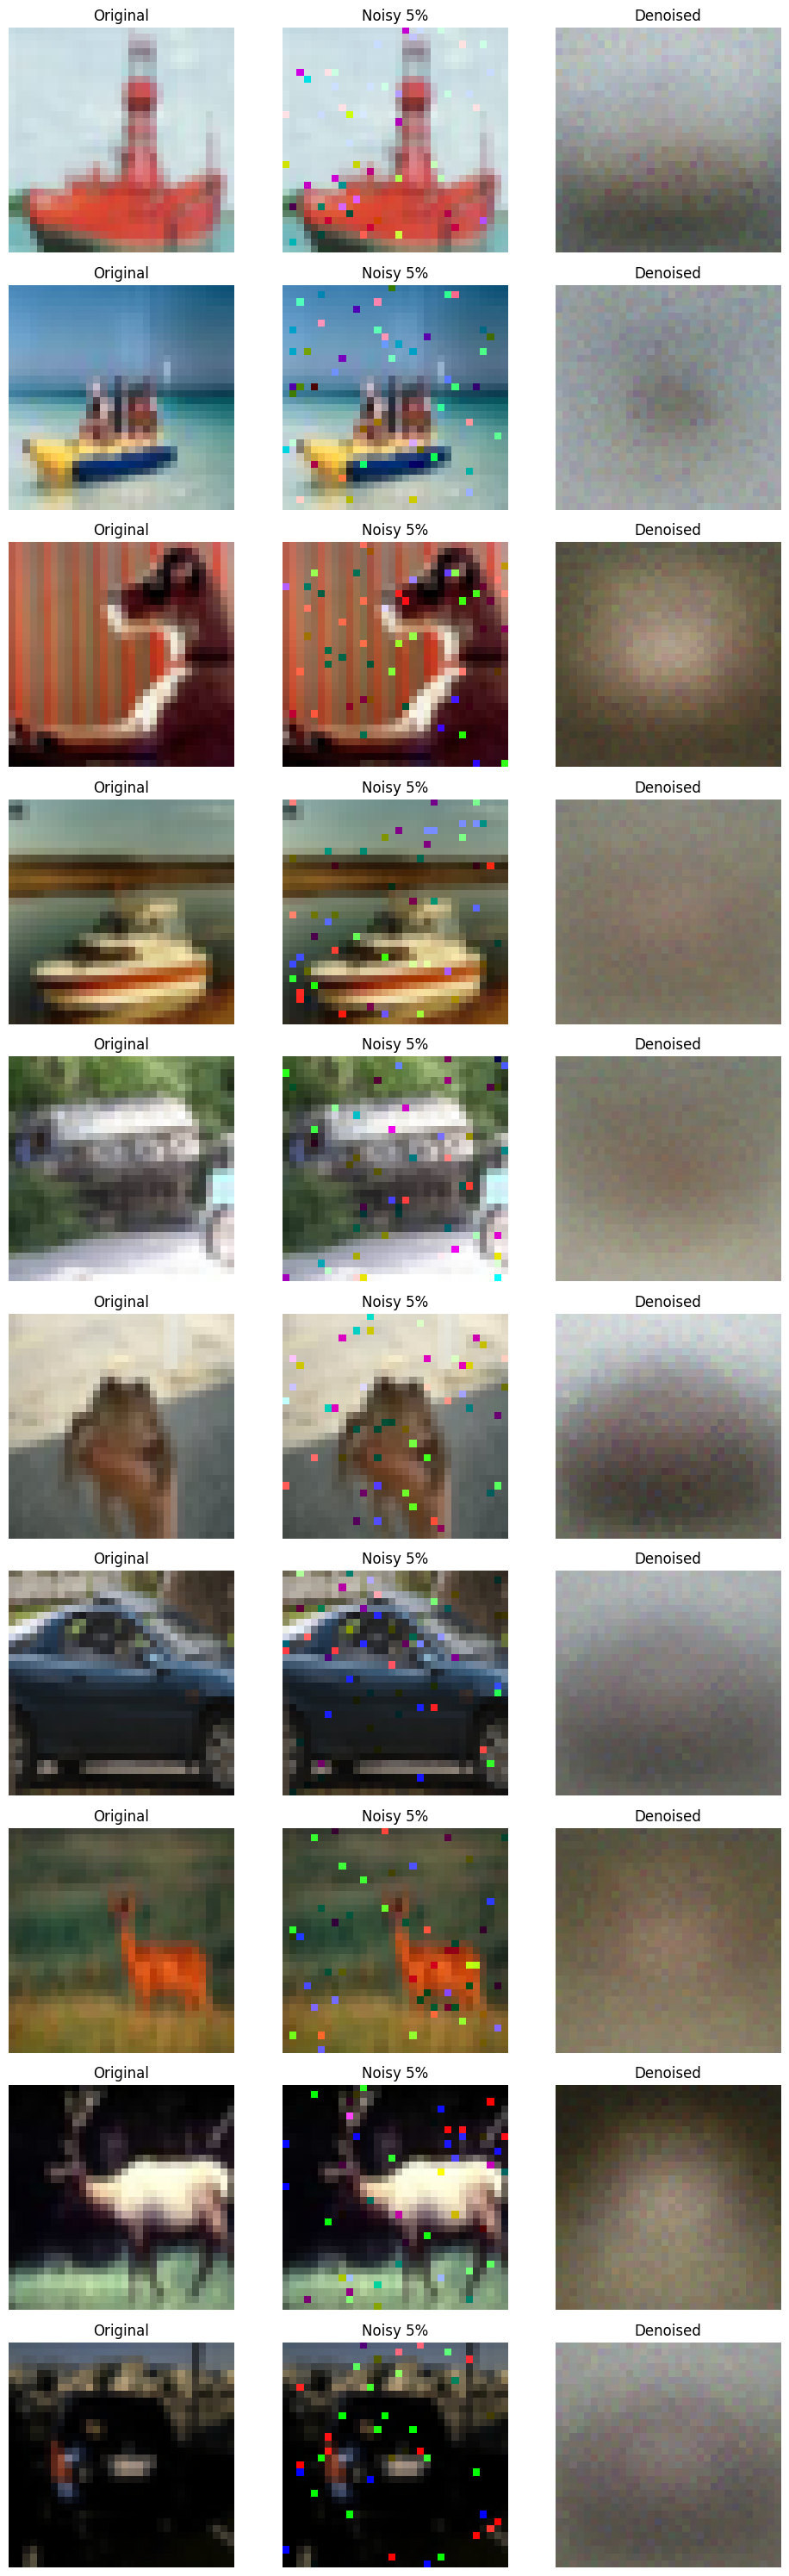

In [19]:
# ---------------------------
# Test on 10 images
# ---------------------------

num_test = 10
test_idx = np.random.choice(len(dataset.data), num_test, replace = False)
X_test = torch.tensor(dataset.data[test_idx] / 255.0).float()


# Select 10 test images
test_indices = np.random.choice(len(X_test), 10, replace=False)
X_samples = X_test[test_indices]

# ----------------------------
# Noise Level 1: 5%
# ----------------------------
noise_ratio = 0.05
X_noisy = add_salt_pepper_noise(X_samples, noise_ratio)
X_noisy_flat = X_noisy.reshape(10, -1)
with torch.no_grad():
    X_denoised_flat = model(X_noisy_flat)
X_denoised = X_denoised_flat.reshape(10,32,32,3)

# Plot all 10 images (Original, Noisy, Denoised)
fig, axs = plt.subplots(10, 3, figsize=(10, 30))
for i in range(10):
    axs[i,0].imshow(X_samples[i].numpy())
    axs[i,0].set_title("Original")
    axs[i,0].axis('off')
    
    axs[i,1].imshow(X_noisy[i].numpy())
    axs[i,1].set_title("Noisy 5%")
    axs[i,1].axis('off')
    
    axs[i,2].imshow(X_denoised[i].numpy())
    axs[i,2].set_title("Denoised")
    axs[i,2].axis('off')
plt.tight_layout()
plt.show()

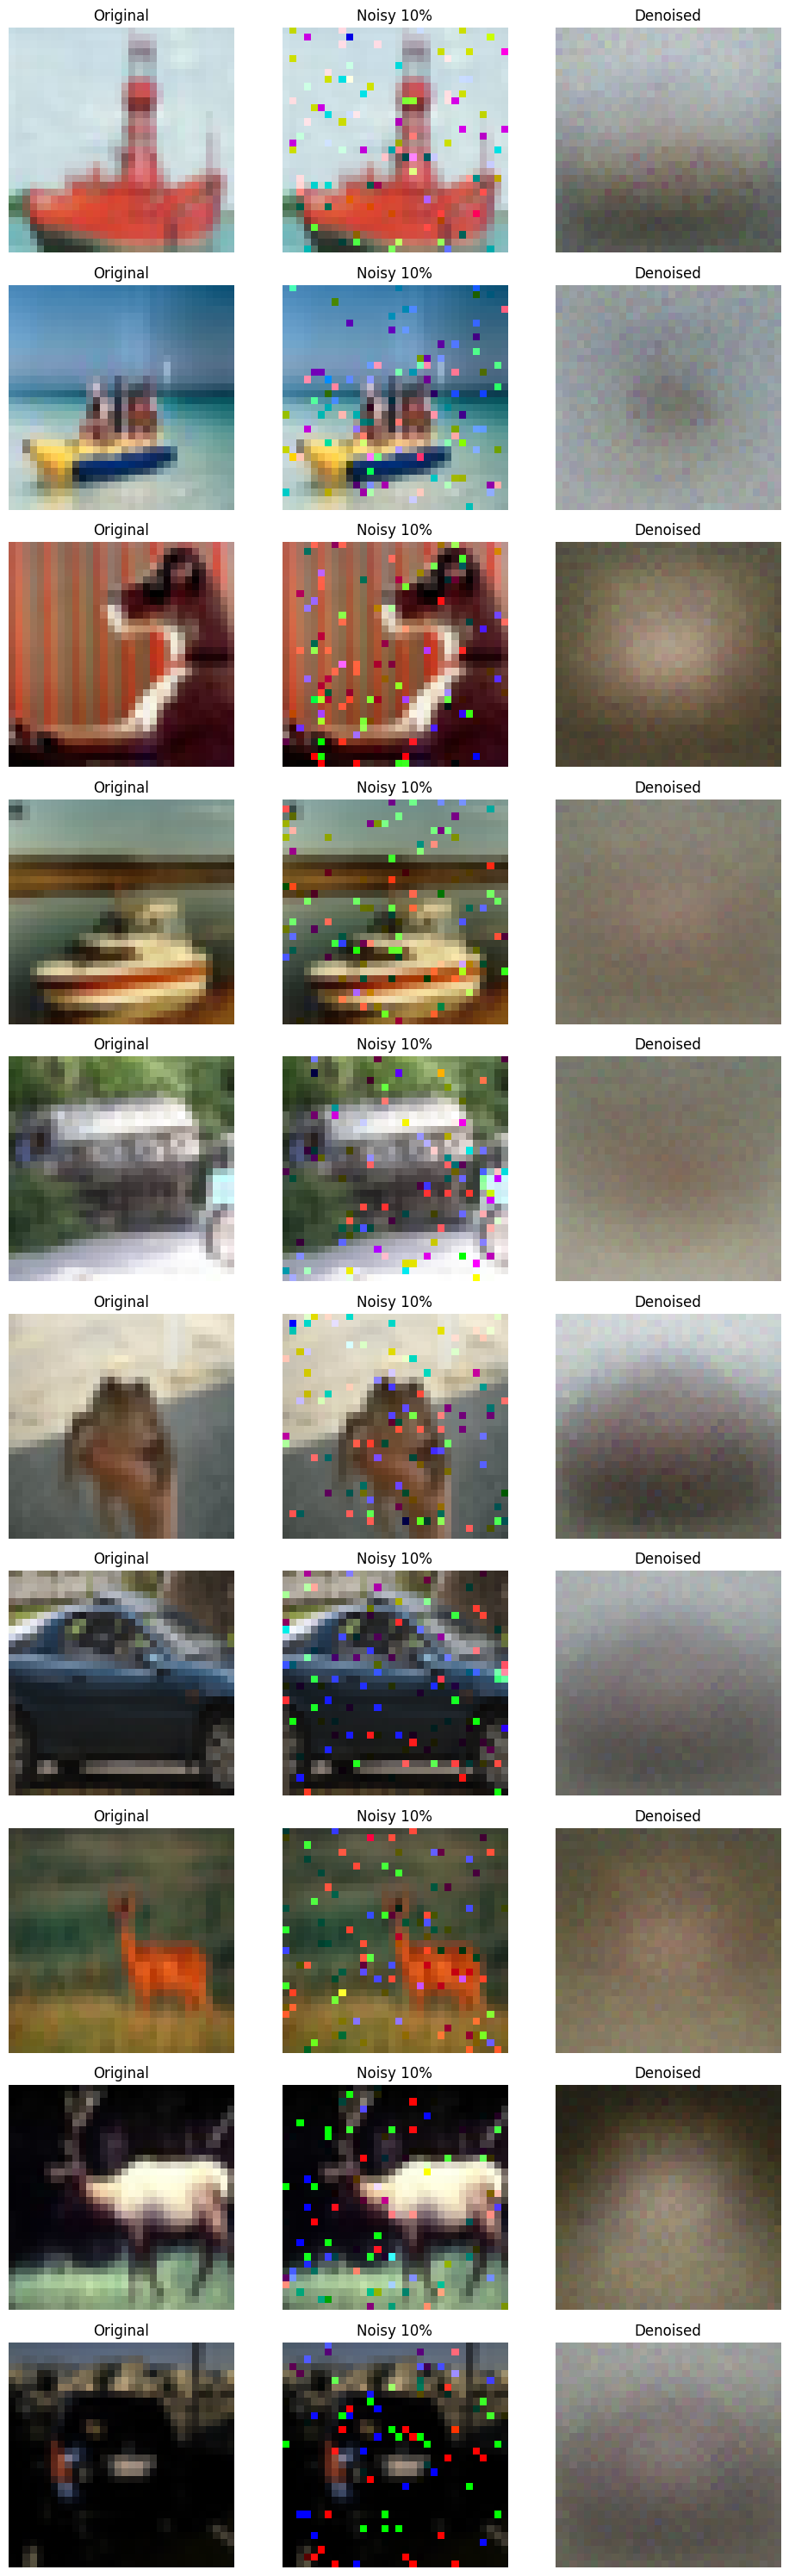

In [20]:
# ----------------------------
# Noise Level 2: 10%
# ----------------------------
noise_ratio = 0.10
X_noisy = add_salt_pepper_noise(X_samples, noise_ratio)
X_noisy_flat = X_noisy.reshape(10, -1)
with torch.no_grad():
    X_denoised_flat = model(X_noisy_flat)
X_denoised = X_denoised_flat.reshape(10,32,32,3)

fig, axs = plt.subplots(10, 3, figsize=(10, 30))
for i in range(10):
    axs[i,0].imshow(X_samples[i].numpy())
    axs[i,0].set_title("Original")
    axs[i,0].axis('off')
    
    axs[i,1].imshow(X_noisy[i].numpy())
    axs[i,1].set_title("Noisy 10%")
    axs[i,1].axis('off')
    
    axs[i,2].imshow(X_denoised[i].numpy())
    axs[i,2].set_title("Denoised")
    axs[i,2].axis('off')
plt.tight_layout()
plt.show()

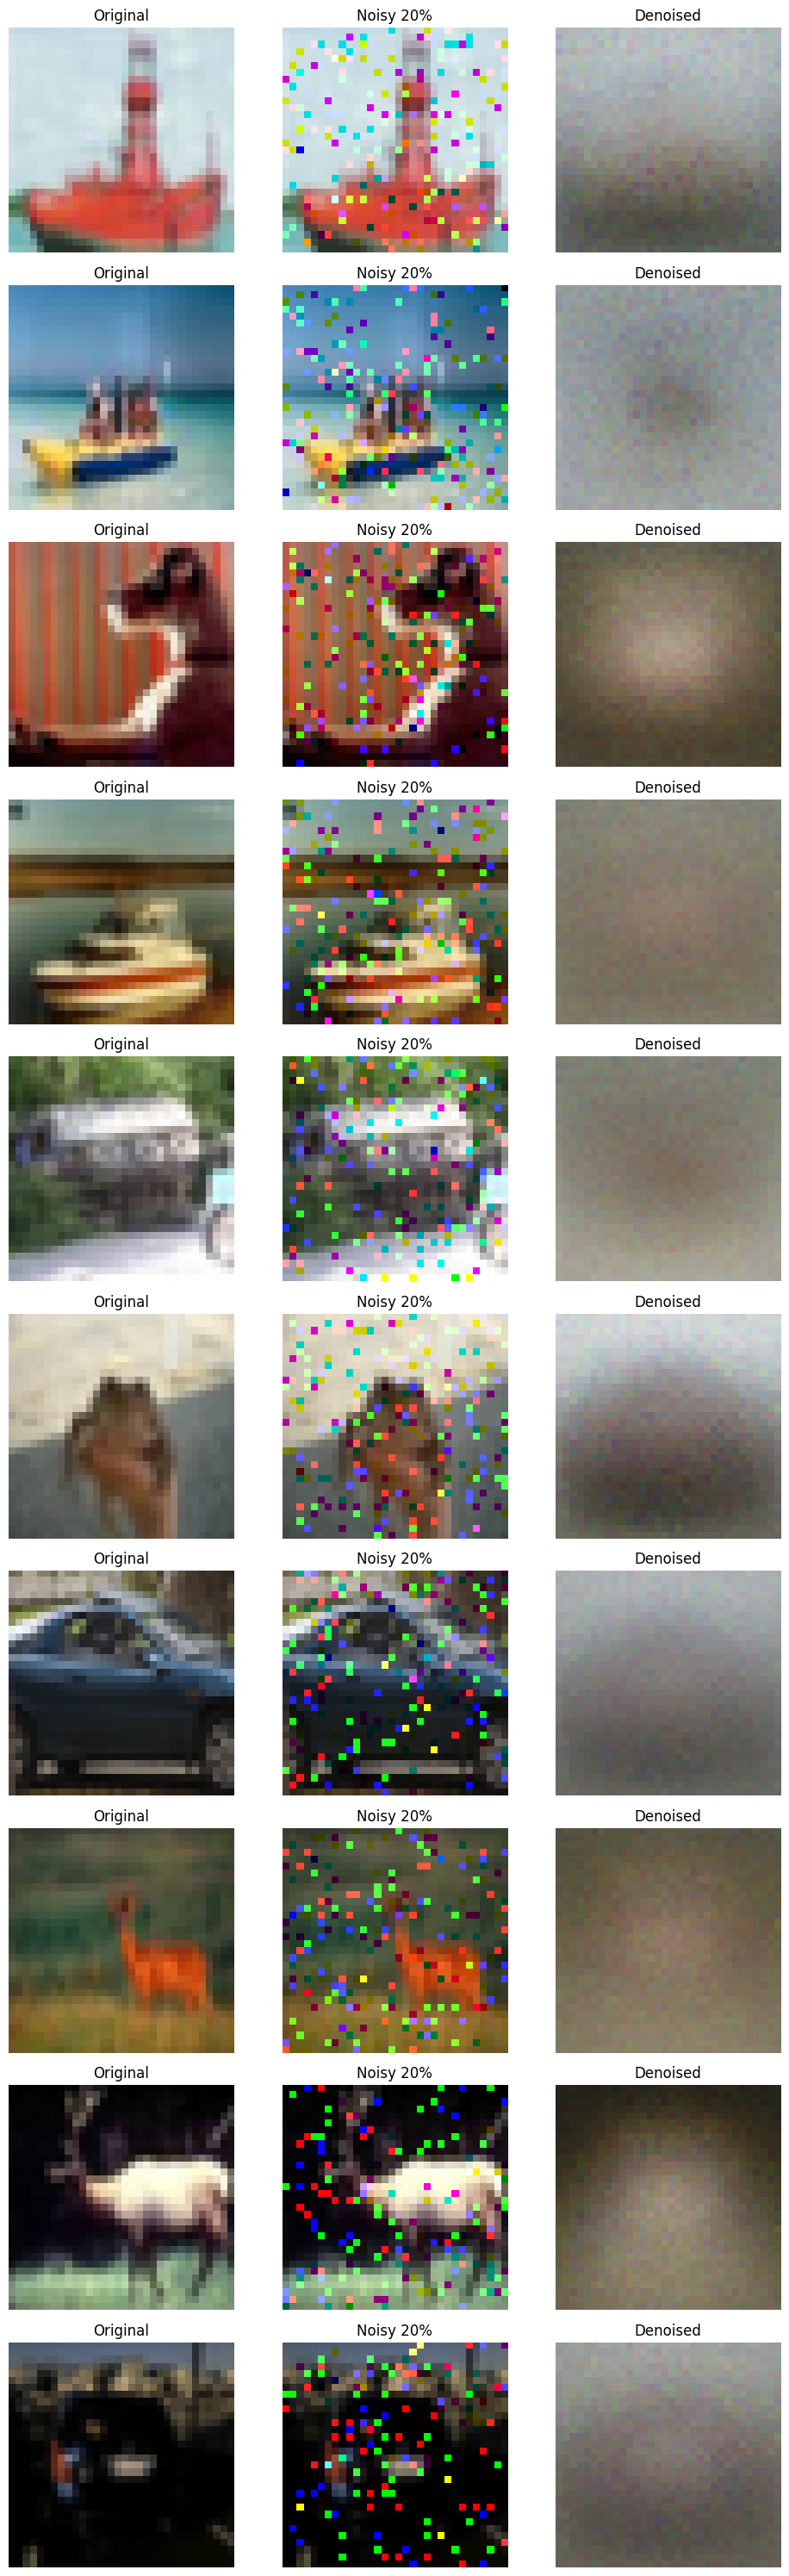

In [21]:
# ----------------------------
# Noise Level 3: 20%
# ----------------------------
noise_ratio = 0.20
X_noisy = add_salt_pepper_noise(X_samples, noise_ratio)
X_noisy_flat = X_noisy.reshape(10, -1)
with torch.no_grad():
    X_denoised_flat = model(X_noisy_flat)
X_denoised = X_denoised_flat.reshape(10,32,32,3)

fig, axs = plt.subplots(10, 3, figsize=(10, 30))
for i in range(10):
    axs[i,0].imshow(X_samples[i].numpy())
    axs[i,0].set_title("Original")
    axs[i,0].axis('off')
    
    axs[i,1].imshow(X_noisy[i].numpy())
    axs[i,1].set_title("Noisy 20%")
    axs[i,1].axis('off')
    
    axs[i,2].imshow(X_denoised[i].numpy())
    axs[i,2].set_title("Denoised")
    axs[i,2].axis('off')
plt.tight_layout()
plt.show()

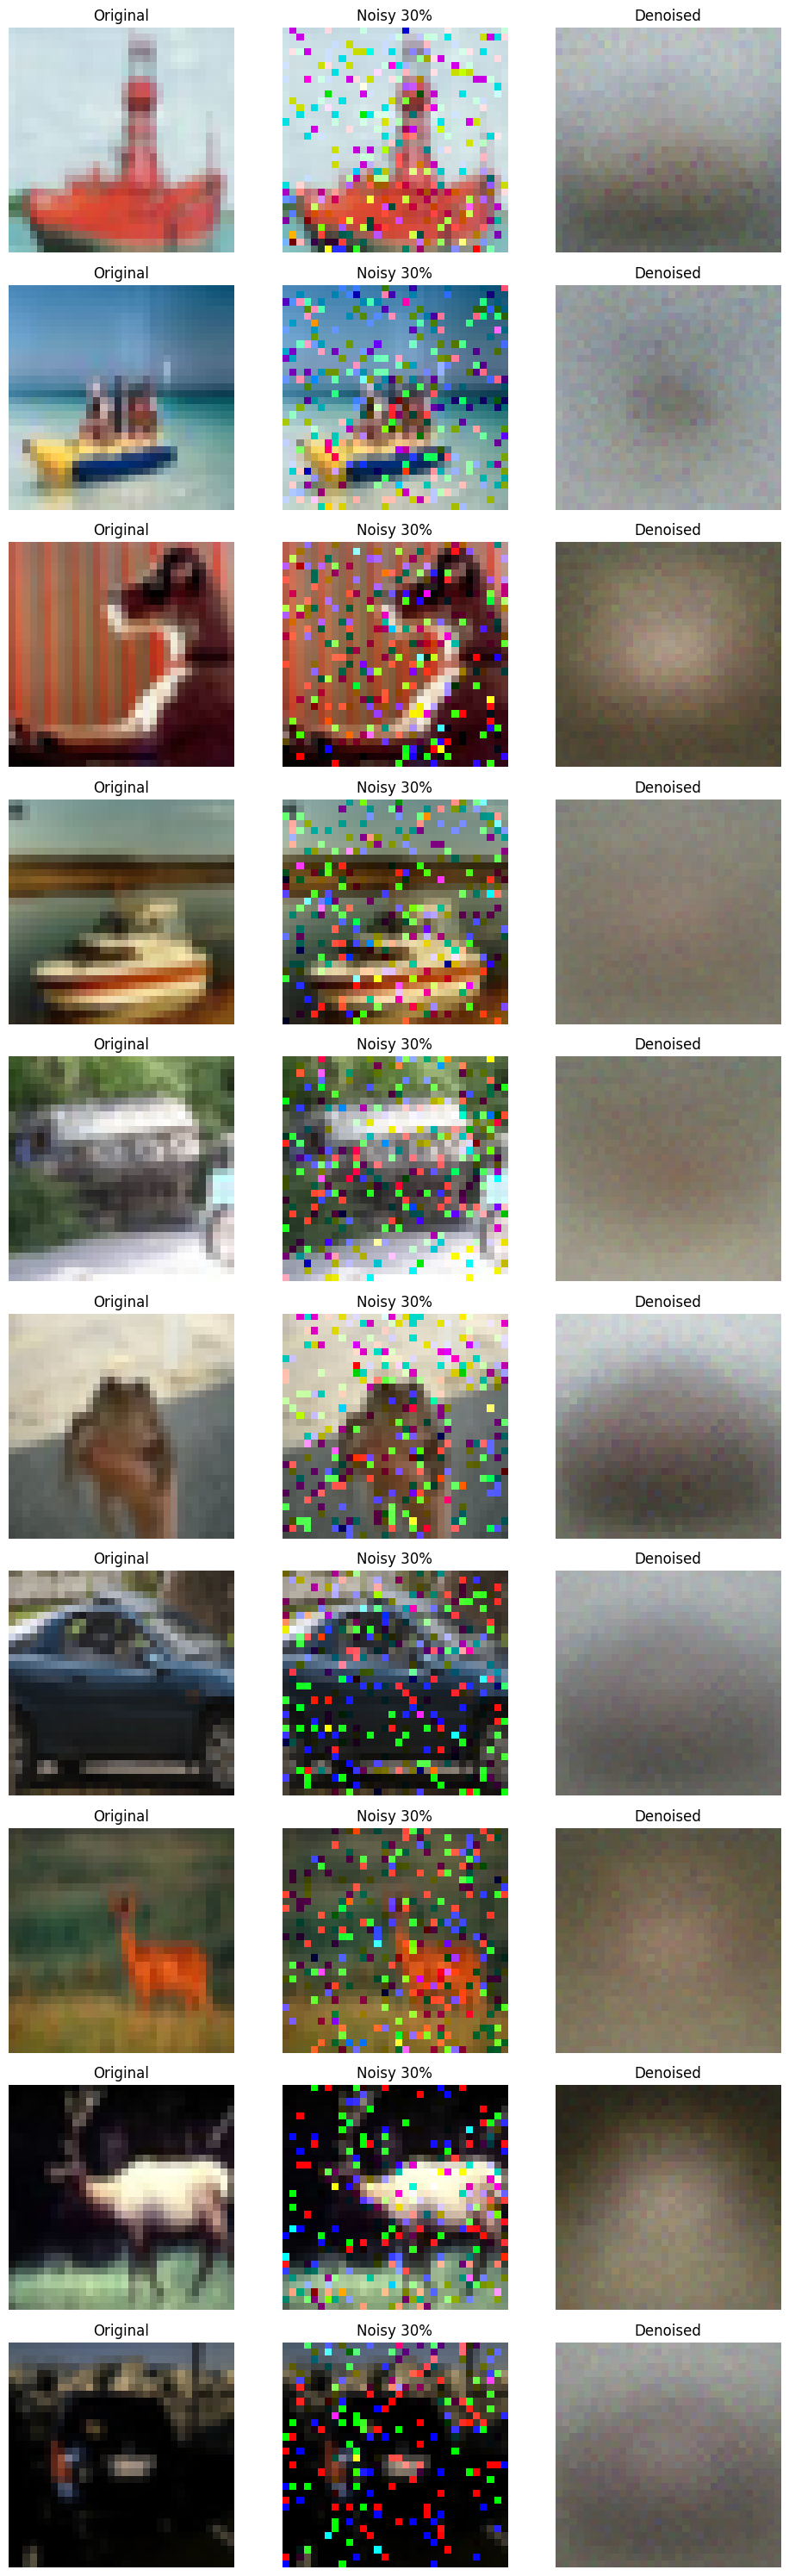

In [22]:
# ----------------------------
# Noise Level 4: 30%
# ----------------------------
noise_ratio = 0.30
X_noisy = add_salt_pepper_noise(X_samples, noise_ratio)
X_noisy_flat = X_noisy.reshape(10, -1)
with torch.no_grad():
    X_denoised_flat = model(X_noisy_flat)
X_denoised = X_denoised_flat.reshape(10,32,32,3)

fig, axs = plt.subplots(10, 3, figsize=(10, 30))
for i in range(10):
    axs[i,0].imshow(X_samples[i].numpy())
    axs[i,0].set_title("Original")
    axs[i,0].axis('off')
    
    axs[i,1].imshow(X_noisy[i].numpy())
    axs[i,1].set_title("Noisy 30%")
    axs[i,1].axis('off')
    
    axs[i,2].imshow(X_denoised[i].numpy())
    axs[i,2].set_title("Denoised")
    axs[i,2].axis('off')
plt.tight_layout()
plt.show()

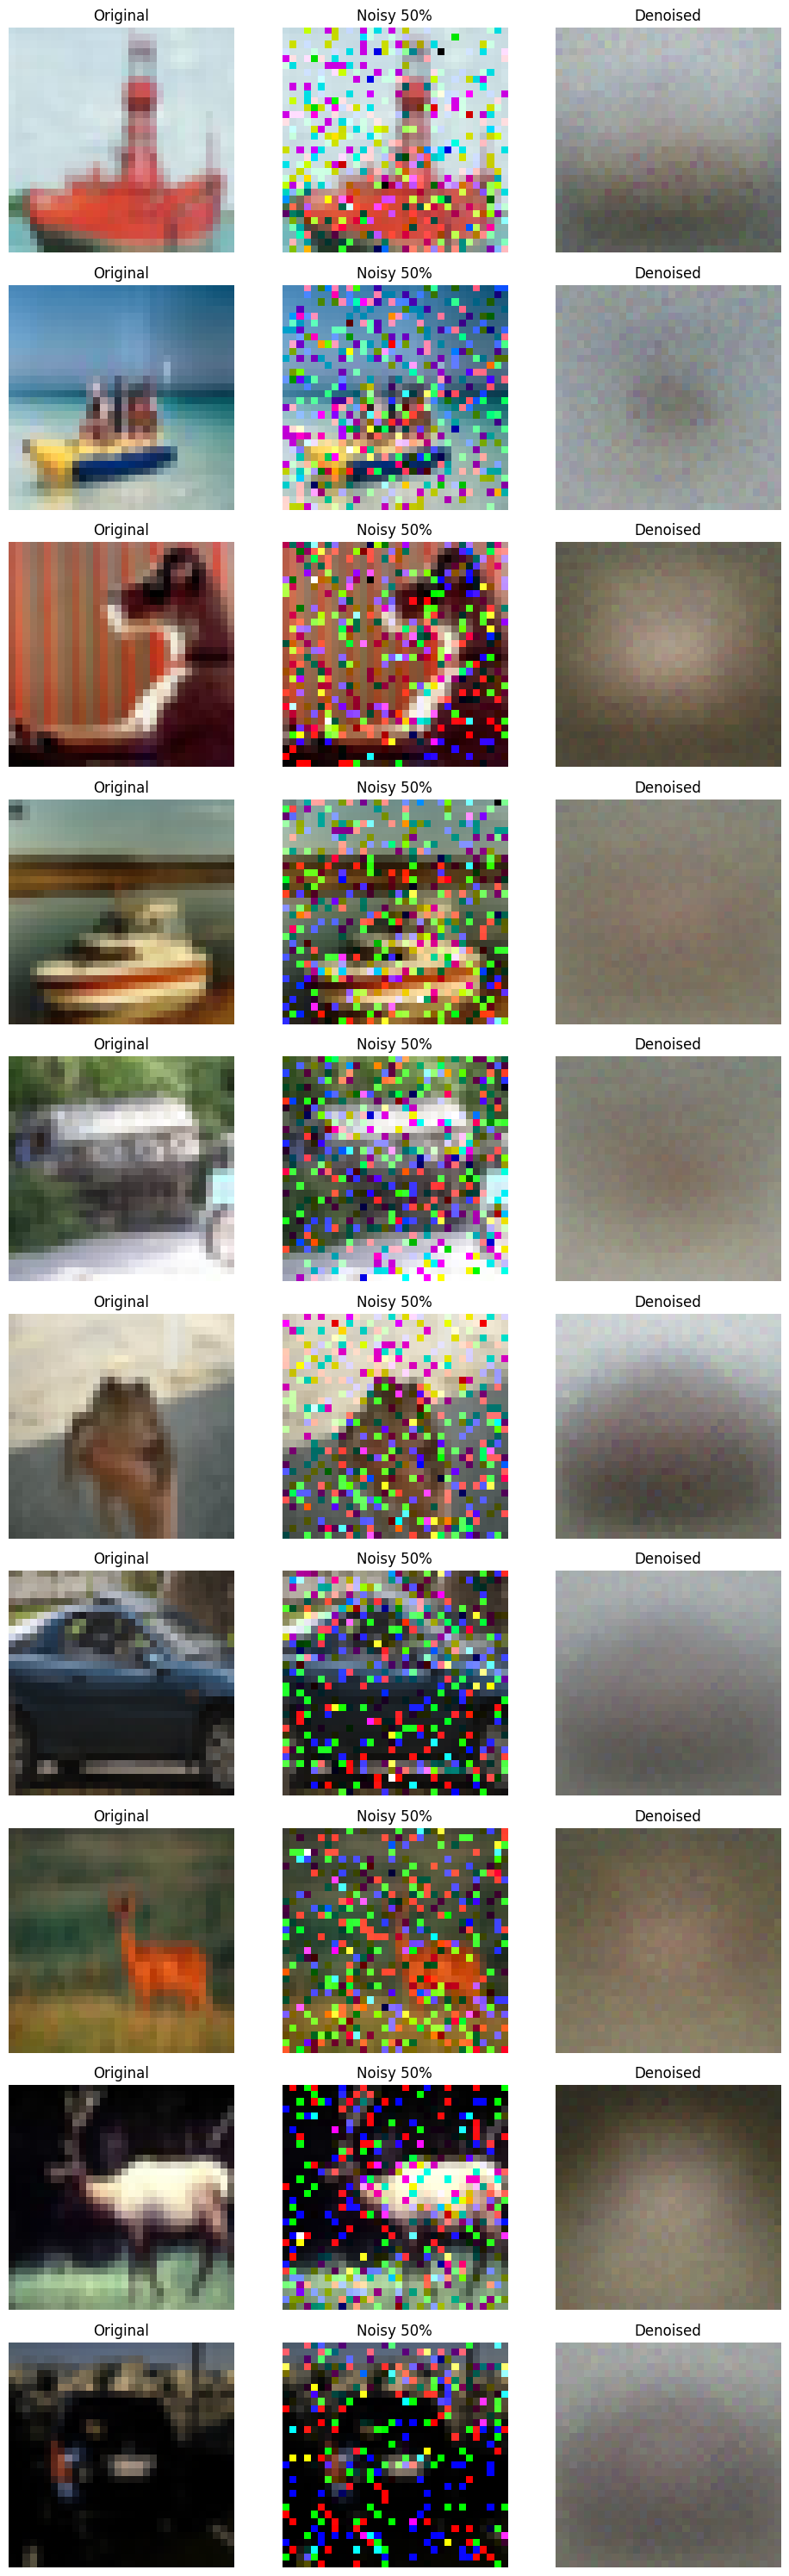

In [23]:
# ----------------------------
# Noise Level 5: 50%
# ----------------------------
noise_ratio = 0.50
X_noisy = add_salt_pepper_noise(X_samples, noise_ratio)
X_noisy_flat = X_noisy.reshape(10, -1)
with torch.no_grad():
    X_denoised_flat = model(X_noisy_flat)
X_denoised = X_denoised_flat.reshape(10,32,32,3)

fig, axs = plt.subplots(10, 3, figsize=(10, 30))
for i in range(10):
    axs[i,0].imshow(X_samples[i].numpy())
    axs[i,0].set_title("Original")
    axs[i,0].axis('off')
    
    axs[i,1].imshow(X_noisy[i].numpy())
    axs[i,1].set_title("Noisy 50%")
    axs[i,1].axis('off')
    
    axs[i,2].imshow(X_denoised[i].numpy())
    axs[i,2].set_title("Denoised")
    axs[i,2].axis('off')
plt.tight_layout()
plt.show()

Question 4

I don't have a saved version of a model, so I wrote a new one

In [24]:
# -----------------------------
# 1. Prepare MNIST data
# -----------------------------
transform = transforms.ToTensor()

train_dataset = datasets.MNIST(root="./data", train=True, download=True, transform=transform)
test_dataset = datasets.MNIST(root="./data", train=False, download=True, transform=transform)

batch_size = 64
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

# -----------------------------
# 2. Define a small FCNN
# -----------------------------
class MNIST_FC(nn.Module):
    def __init__(self):
        super().__init__()
        self.flatten = nn.Flatten()
        self.fc = nn.Sequential(
            nn.Linear(28*28, 256),  # input layer -> hidden
            nn.ReLU(),
            nn.Linear(256, 128),    # hidden -> hidden
            nn.ReLU(),
            nn.Linear(128, 10)      # hidden -> output
        )
    def forward(self, x):
        x = self.flatten(x)
        return self.fc(x)

# -----------------------------
# 3. Setup model, loss, optimizer
# -----------------------------
device = "cuda" if torch.cuda.is_available() else "cpu"
model = MNIST_FC().to(device)

loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

# -----------------------------
# 4. Training loop
# -----------------------------
epochs = 5  # quick training for demonstration

for epoch in range(epochs):
    model.train()
    for X, y in train_loader:
        X, y = X.to(device), y.to(device)
        optimizer.zero_grad()
        output = model(X)
        loss = loss_fn(output, y)
        loss.backward()
        optimizer.step()
    print(f"Epoch {epoch+1}/{epochs}, Loss: {loss.item():.4f}")

# -----------------------------
# 5. Test accuracy
# -----------------------------
model.eval()
correct, total = 0, 0
with torch.no_grad():
    for X, y in test_loader:
        X, y = X.to(device), y.to(device)
        preds = model(X).argmax(dim=1)
        correct += (preds == y).sum().item()
        total += y.size(0)

print(f"Test Accuracy: {100*correct/total:.2f}%")

Epoch 1/5, Loss: 0.3890
Epoch 2/5, Loss: 0.0171
Epoch 3/5, Loss: 0.0188
Epoch 4/5, Loss: 0.1441
Epoch 5/5, Loss: 0.0049
Test Accuracy: 97.73%


In [25]:
# ---------------------------------------
# Create skewed MNIST dataset
# ---------------------------------------
from torch.utils.data import DataLoader, Subset
from torchvision import datasets, transforms
import numpy as np

# Load MNIST test set
transform = transforms.ToTensor()
test_dataset = datasets.MNIST(root='./data', train=False, download=True, transform=transform)

# Target counts for the skewed dataset
target_counts = {0:1000, 1:1000, 2:1000, 3:640, 4:320, 5:160, 6:80, 7:40, 8:20, 9:10}

# Convert test labels to numpy array
targets_np = test_dataset.targets.numpy()

# Get all indices by label
indices_by_class = {i: np.where(targets_np == i)[0] for i in range(10)}

# Select indices for the skewed dataset
selected_indices = []
for digit, count in target_counts.items():
    idx = np.random.choice(indices_by_class[digit], count, replace=True)  # allow replacement if needed
    selected_indices.extend(idx)

# Create Subset and DataLoader
skewed_test_dataset = Subset(test_dataset, selected_indices)
batch_size = 64
skewed_test_loader = DataLoader(skewed_test_dataset, batch_size=batch_size, shuffle=False)

In [26]:
# --------------------------------
# Test on skewed data
# --------------------------------

model.eval()
device = "cuda" if torch.cuda.is_available() else "cpu"
model.to(device)

correct, total = 0, 0
with torch.no_grad():
    for X, y in skewed_test_loader:
        X, y = X.to(device), y.to(device)
        preds = model(X).argmax(dim=1)
        correct += (preds == y).sum().item()
        total += y.size(0)

accuracy_skewed = correct / total
print(f"Accuracy on skewed test set: {accuracy_skewed*100:.2f}%")

Accuracy on skewed test set: 98.74%


As shown, the accuracy is different and slightly increased. This is because the
model is seeing a different class distribution, and accuracy is dataset-dependent.  